# RL agent sims (260715): model characterisation by centrality strategy

~40 social (2-agent) self-play models trained in `Octagon/results/2607/260715`. Per `notes_260715.txt` these are **seed-replicate models**: identical config to the 0.01-RND / no-penalty-break agents of 260624, but with a **random seed per run** instead of a fixed trial sequence. The only deliberate parameter change within the set is training length — **from model 25 the total training steps was cut from 4e6 to 3e6**.

Because the models share parameters and differ mainly by seed, the quantity of interest is the **between-model variability**. The goal is to split it into a *gross strategy* axis and *intra-strategy variability*, then pick a spread of models for a tournament.

**The characterisation axis is centrality at slice onset.** For each trial, at the frame the walls appear, centrality `= 1 - r/R` (1 = arena centre, 0 = at a wall). A model's mean over trials is roughly where it stands when the trial starts, and defines a broadly central or broadly peripheral waiting strategy.

**Plan**
1. **Gross strategy** — per-model slice-onset centrality, split into central vs peripheral.
2. **Intra-strategy variability** — how the other behavioural metrics vary within each strategy, and which metrics separate the strategies vs vary freely inside them.
3. A shortlist of models for the tournament.

> **Data note.** Reads the social self-play inference logs at `~/Unity/Octagon/simulations/2607/260715/` (one `260715_NNNN` subfolder per model, same layout as 260624). Nothing below is hard-coded to a model list, so it picks up whatever models are present. Runs with no completed trials are skipped (see the main pass).

**Choices** (matching prior sim notebooks): FoV = 110.0; both agents pooled (self-play); loading reused from `parse_data/` (`prepare_sim_data` -> `preprocess_sim`); slice-onset position via `get_indices.get_player_slice_onset_loc`.

In [1]:
import os
import io
import contextlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats

import data_strings
import globals
from parse_data import prepare_sim_data, identify_sim_filepaths
import data_extraction.get_indices as get_indices
import trajectory_analysis.trajectory_headangle as trajectory_headangle
import plotting.plot_octagon as plot_octagon

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

# social self-play inference logs for this run live in a dated subfolder
SIM_DATA_FOLDER = os.path.join(data_strings.SIM_DATA_FOLDER, '2607', '260715')

CURRENT_FOV = 110.0                 # agent camera FoV (total degrees); get_wall_visible tests theta < FoV/2
FS = globals.RECORDING_FREQUENCY    # 50 Hz logging
ARENA_RADIUS = 36.21 / 2            # octagon centred at (0, 0); centrality 1 = centre, 0 = wall
ITI_EPOCHS = [globals.ITI, globals.TRIAL_STARTED]  # "ITI" here = trial end -> next slice onset
STATIONARY_SPEED = 0.05             # units/frame; below this a frame counts as "not moving"
PLAYERS = (0, 1)                    # self-play: pool both agents

In [2]:
# the only deliberate parameter difference within the set is training length
# notes_260715.txt: "From model 25, total training steps was reduced from 4e06 to 3e06".
TRAIN_STEP_CUTOFF = 25
def train_steps(model):
    return '3e6' if model >= TRAIN_STEP_CUTOFF else '4e6'

TRAIN_PALETTE = {'4e6': '#4C72B0', '3e6': '#DD8452'}

# discover whatever models are present (seed replicates, no a-priori strategy groups)
model_folders = identify_sim_filepaths.get_model_folders(sim_data_folder=SIM_DATA_FOLDER)
ALL_MODELS = sorted(num for num, _ in model_folders)
print(f"models found: {len(ALL_MODELS)}")
print(ALL_MODELS)
print(f"4e6-step models (< {TRAIN_STEP_CUTOFF}): {[m for m in ALL_MODELS if m < TRAIN_STEP_CUTOFF]}")
print(f"3e6-step models (>= {TRAIN_STEP_CUTOFF}): {[m for m in ALL_MODELS if m >= TRAIN_STEP_CUTOFF]}")

models found: 39
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
4e6-step models (< 25): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
3e6-step models (>= 25): [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


## Metric functions

One pass per model produces four tables. To stay memory-safe over ~40 models (~90k rows each) the loop loads one model, computes everything, then discards its dataframe. The functions below are reused unchanged from `scanning_behaviour_demo`, plus the new **slice-onset centrality** metric.

In [3]:
def slice_onset_centrality(trial, player_id):
    ''' Return the centrality of one agent at its slice-onset frame (1 = centre, 0 = wall),
        plus the raw x,z for occupancy maps. Takes a trial and player id.
        Returns None if the slice onset or position is missing. '''
    x, z = get_indices.get_player_slice_onset_loc(trial, player_id)
    x, z = float(x), float(z)
    if np.isnan(x) or np.isnan(z):
        return None
    return dict(player=player_id, x=x, z=z,
                centrality=float(1 - np.hypot(x, z) / ARENA_RADIUS))


def iti_metrics(df, player_id):
    ''' Return one row per ITI (trial end -> next slice onset) with scanning (yaw rotation),
        movement (path length, stationary fraction) and resting centrality for one agent.
        Takes a session dataframe and player id. '''
    xcol = globals.PLAYER_LOC_DICT[player_id]['xloc']
    zcol = globals.PLAYER_LOC_DICT[player_id]['yloc']
    ycol = globals.PLAYER_ROT_DICT[player_id]['yrot']  # yaw rotation (degrees)

    is_iti = df['trial_epoch'].isin(ITI_EPOCHS)
    run_id = (is_iti != is_iti.shift()).cumsum()            # id each contiguous ITI/non-ITI run

    rows = []
    for _, grp in df[is_iti].groupby(run_id[is_iti]):
        yaw = grp[ycol].to_numpy(float); yaw = yaw[~np.isnan(yaw)]
        x = grp[xcol].to_numpy(float); z = grp[zcol].to_numpy(float)
        ok = ~np.isnan(x) & ~np.isnan(z); x, z = x[ok], z[ok]
        if len(yaw) < 3 or len(x) < 3:
            continue
        unw = np.rad2deg(np.unwrap(np.deg2rad(yaw)))         # unwrap so large spins don't fold back
        step = np.hypot(np.diff(x), np.diff(z))              # per-frame translation
        rows.append(dict(
            player=player_id,
            n_frames=len(yaw),
            rot_range=float(unw.max() - unw.min()),
            rot_total=float(np.abs(np.diff(unw)).sum()),
            path_len=float(step.sum()),
            stationary_frac=float(np.mean(step < STATIONARY_SPEED)),
            iti_centrality=float(1 - np.mean(np.hypot(x, z)) / ARENA_RADIUS),
        ))
    return pd.DataFrame(rows)


def visibility_metrics(trial, player_id, fov=CURRENT_FOV):
    ''' Return the latency (s) until a trial wall first enters the FoV after slice onset, plus
        visible-at-onset / ever-visible flags, for one agent on one trial. Takes a trial and
        player id. Returns None if the trial is too short. '''
    with contextlib.redirect_stdout(io.StringIO()):        # get_wall_visible is chatty on debug paths
        wv = trajectory_headangle.get_wall_visible(trial=trial, player_id=player_id, current_fov=fov)
    if isinstance(wv, float) and np.isnan(wv):
        return None
    idxs = [w - 1 for w in get_indices.get_walls(trial=trial)]   # wall number -> row index
    any_vis = wv[idxs, :].any(axis=0)
    ever = bool(any_vis.any())
    return dict(
        player=player_id,
        latency_s=(int(np.argmax(any_vis)) / FS) if ever else np.nan,
        visible_at_onset=bool(any_vis[0]),
        ever_visible=ever,
    )

## Main pass over all models

Builds `slice_df` (slice-onset centrality, one row per trial x agent), `iti_df`, `vis_df` and `score_df`. Slice-onset x,z are kept so the occupancy heatmaps can be split by strategy after classification.

In [4]:
slice_records, iti_records, vis_records, score_records, rt_records = [], [], [], [], []
failed_models = []      # inference runs with no usable trials (e.g. agent stuck on trial 1)

for model in ALL_MODELS:
    try:
        with contextlib.redirect_stdout(io.StringIO()):      # silence per-model load/preprocess prints
            df, trial_list = prepare_sim_data.prepare_single_model_data(model, sim_data_folder=SIM_DATA_FOLDER)
        if len(trial_list) == 0:
            raise ValueError("no completed trials")
    except Exception as e:
        failed_models.append((model, type(e).__name__))
        print(f"model {model:2d} SKIPPED ({type(e).__name__})", end='  ')
        continue

    # measure ITI movement, scanning and resting position, pooled over agents
    for pid in PLAYERS:
        w = iti_metrics(df, pid)
        w.insert(0, 'model', model)
        iti_records.append(w)

    # per trial, take slice-onset centrality (the strategy axis) and wall visibility for both agents
    for trial in trial_list:
        ttype = trial[globals.TRIAL_TYPE].replace('', np.nan).dropna().unique()
        ttype = ttype[0] if len(ttype) else ''
        for pid in PLAYERS:
            try:
                s = slice_onset_centrality(trial, pid)
            except (IndexError, ValueError):
                s = None                                     # trial missing slice onset
            if s is not None:
                s.update(model=model, trial_type=ttype)
                slice_records.append(s)
            try:
                r = visibility_metrics(trial, pid)
            except (IndexError, ValueError):
                r = None
            if r is not None:
                r.update(model=model, trial_type=ttype)
                vis_records.append(r)

    # take one row per trial outcome. Terminal player score: 1.0 (reached High), 0.4 (reached Low),
    # 0 (lost the race). Analysis uses this SCORE, not agent reward — reward folds in step/time
    # penalties and the no-movement penalty-break, and isn't even applied at inference, so it is not
    # a clean performance measure. Agent 0's score stands for the model (both agents are the same
    # model); score_p1 is kept only to check the two agents score about equally.
    te = df[df['eventDescription'] == globals.TRIAL_END]
    score_records.append(pd.DataFrame(dict(
        model=model,
        score_p0=te[globals.PLAYER_0_TRIAL_SCORE].to_numpy(float),
        score_p1=te[globals.PLAYER_1_TRIAL_SCORE].to_numpy(float))))

    # trial completion time = slice onset -> server-selected trigger activation (drop trial 0), in seconds.
    # a long time means the trial dragged on (e.g. agents standing still until forced to move).
    so = df[df['eventDescription'] == globals.SLICE_ONSET].iloc[1:]
    trig = df[df['eventDescription'] == globals.SELECTED_TRIGGER_ACTIVATION].iloc[1:]
    n_done = len(trig)
    if n_done:
        rt = (trig['timeApplication'].to_numpy()[:n_done] - so['timeApplication'].to_numpy()[:n_done]) / np.timedelta64(1, 's')
        rt_records.append(pd.DataFrame(dict(model=model, rt_s=rt.astype(float))))

    print(f"model {model:2d} done", end='  ')

# stack the per-model records into long tables (one row per trial, ITI, scoring event, or completed trial)
slice_df = pd.DataFrame(slice_records)
iti_df = pd.concat(iti_records, ignore_index=True)
vis_df = pd.DataFrame(vis_records)
score_df = pd.concat(score_records, ignore_index=True)
rt_df = pd.concat(rt_records, ignore_index=True)
# the higher of the two agent scores is the winner's, so 1.0 means High was reached, 0.4 means Low
score_df['winner_score'] = score_df[['score_p0', 'score_p1']].max(axis=1)

# one row per usable model, tagged with its training length; the per-model tables merge onto this
USABLE_MODELS = sorted(slice_df['model'].unique())        # models that produced at least one trial
model_meta = pd.DataFrame({'model': USABLE_MODELS})
model_meta['train_steps'] = model_meta['model'].map(train_steps)
print(f"\n\nusable models: {len(USABLE_MODELS)} / {len(ALL_MODELS)}")
if failed_models:
    print(f"skipped (no usable trials): {failed_models}")
print(f"slice-onset rows: {len(slice_df)} | ITIs: {len(iti_df)} | "
      f"visibility rows: {len(vis_df)} | scored trials: {len(score_df)}")
tc = score_df.groupby('model').size()
print(f"trials per model: min {tc.min()}, max {tc.max()}")

model  1 done  

model  2 done  

model  3 done  

model  4 done  

model  5 done  

...

model 35 done  

model 36 done  

model 37 done  

model 38 done  

model 39 done  

usable models: 37 / 39
skipped (no usable trials): [(18, 'TypeError'), (19, 'TypeError')]
slice-onset rows: 14694 | ITIs: 14768 | visibility rows: 12476 | scored trials: 7347
trials per model: min 194, max 199


## Stage 1 - the strategy axis (centrality at slice onset)

Each model's mean slice-onset centrality summarises its strategy. Models are ranked by it (bar = mean, whisker = SD across trials), with the spread of individual trials shown below. A tight spread means the model starts most trials from a similar distance out; a wide one means its start position varies a lot.

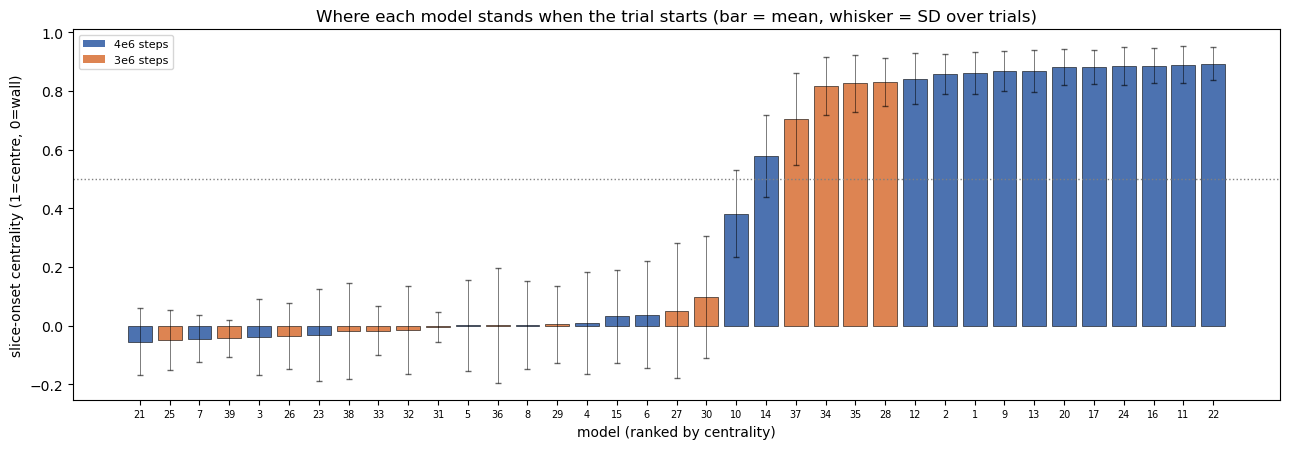

In [5]:
onset_by_model = (slice_df.groupby('model')['centrality']
                  .agg(onset_centrality='mean', onset_sd='std', n='size').reset_index())
onset_by_model['train_steps'] = onset_by_model['model'].map(train_steps)
model_meta = model_meta.merge(onset_by_model[['model', 'onset_centrality', 'onset_sd']], on='model')

order = onset_by_model.sort_values('onset_centrality').reset_index(drop=True)
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.bar(x, order['onset_centrality'], yerr=order['onset_sd'], capsize=2,
       color=[TRAIN_PALETTE[t] for t in order['train_steps']], edgecolor='black', linewidth=0.4,
       error_kw=dict(lw=0.6, alpha=0.6))
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_xticks(x); ax.set_xticklabels(order['model'], fontsize=7)
ax.set_xlabel('model (ranked by centrality)'); ax.set_ylabel('slice-onset centrality (1=centre, 0=wall)')
ax.set_title('Where each model stands when the trial starts (bar = mean, whisker = SD over trials)')
ax.legend(handles=[Patch(facecolor=TRAIN_PALETTE[t], label=f'{t} steps') for t in ['4e6', '3e6']], fontsize=8)
plt.tight_layout(); plt.show()

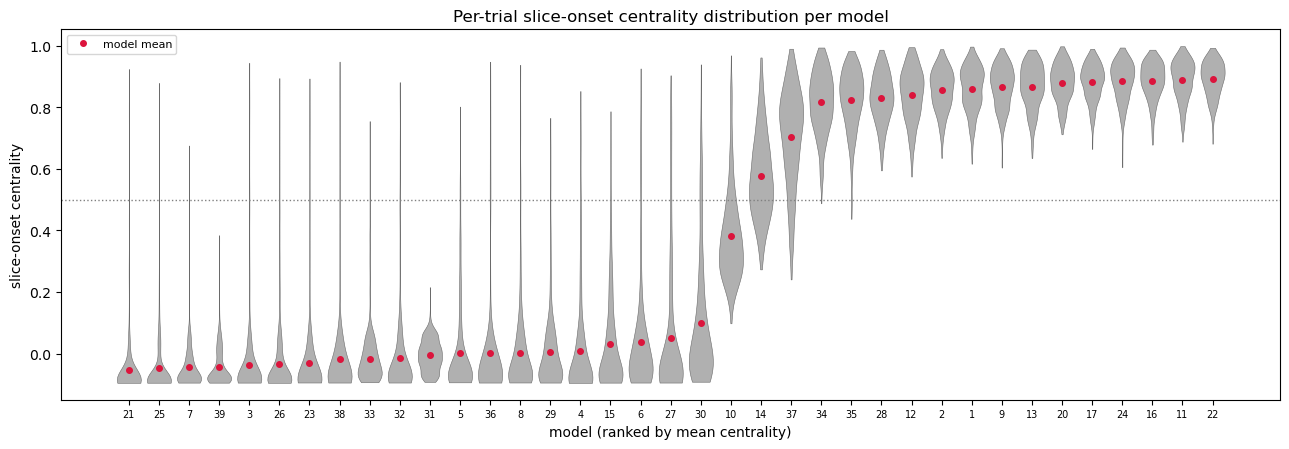

In [6]:
# plot the per-trial spread within each model, ordered by model mean
fig, ax = plt.subplots(figsize=(13, 4.6))
mean_order = onset_by_model.sort_values('onset_centrality')['model'].tolist()
sns.violinplot(data=slice_df, x='model', y='centrality', order=mean_order,
               density_norm='width', inner=None, cut=0, linewidth=0.4,
               color='#B0B0B0', ax=ax)
ax.plot(range(len(mean_order)),
        onset_by_model.set_index('model').loc[mean_order, 'onset_centrality'].values,
        'o', color='crimson', markersize=4, label='model mean')
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_xticks(range(len(mean_order)))
ax.set_xticklabels(mean_order, fontsize=7)
ax.set_xlabel('model (ranked by mean centrality)'); ax.set_ylabel('slice-onset centrality')
ax.set_title('Per-trial slice-onset centrality distribution per model')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Data-driven central vs peripheral split

Are "central" and "peripheral" two separate clusters, or just ends of one continuous range? The models are split two ways. (a) A fixed cut at centrality = 0.5, nearer the centre than a wall. (b) A 2-component Gaussian mixture fit to the per-model means, which finds its own boundary. If the two splits agree and the distribution has a clear gap, the split is real. If they disagree over a smooth spread, centrality is a sliding scale, not two groups.

GMM component means: [0.013 0.835]  weights: [0.57 0.43]
fixed(0.5) vs GMM agreement: 100%
strategy_gmm  strategy_fixed
central       central           16
peripheral    peripheral        21
Name: n, dtype: int64


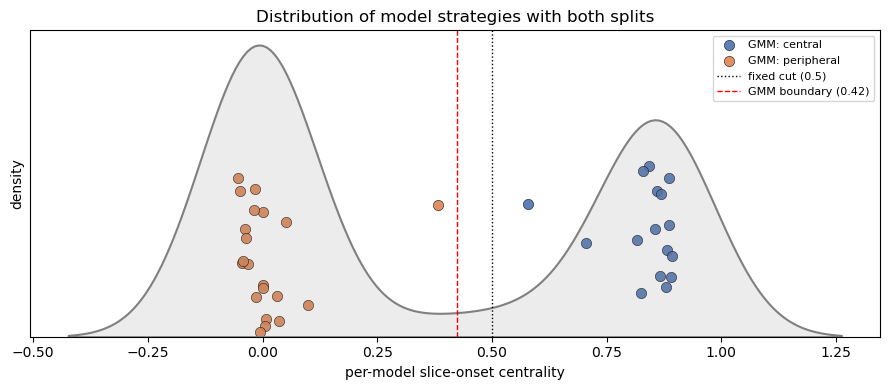

In [7]:
vals = onset_by_model['onset_centrality'].to_numpy()

# (a) fixed absolute threshold
onset_by_model['strategy_fixed'] = np.where(vals > 0.5, 'central', 'peripheral')

# (b) 2-component Gaussian mixture on the 1-D per-model means
gmm = GaussianMixture(n_components=2, n_init=10, random_state=0).fit(vals.reshape(-1, 1))
comp = gmm.predict(vals.reshape(-1, 1))
central_comp = int(np.argmax(gmm.means_.ravel()))            # higher-centrality component = central
onset_by_model['strategy_gmm'] = np.where(comp == central_comp, 'central', 'peripheral')
boundary = np.mean(gmm.means_.ravel())                       # rough visual divider between the two means

agree = (onset_by_model['strategy_fixed'] == onset_by_model['strategy_gmm']).mean()
print(f"GMM component means: {np.sort(gmm.means_.ravel()).round(3)}  weights: {gmm.weights_.round(2)}")
print(f"fixed(0.5) vs GMM agreement: {agree:.0%}")
print(onset_by_model.groupby(['strategy_gmm', 'strategy_fixed']).size().rename('n'))

fig, ax = plt.subplots(figsize=(9, 4))
for lab, col in [('central', '#4C72B0'), ('peripheral', '#DD8452')]:
    sub = onset_by_model[onset_by_model['strategy_gmm'] == lab]
    ax.scatter(sub['onset_centrality'], np.random.uniform(0, 1, len(sub)),
               color=col, edgecolor='black', linewidth=0.4, s=55, alpha=0.9, label=f'GMM: {lab}')
    for _, r in sub.iterrows():
        ax.annotate(int(r['model']), (r['onset_centrality'], 0), fontsize=6, alpha=0)
sns.kdeplot(x=vals, ax=ax, color='grey', lw=1.5, fill=True, alpha=0.15, bw_adjust=0.6)
ax.axvline(0.5, color='black', ls=':', lw=1, label='fixed cut (0.5)')
ax.axvline(boundary, color='red', ls='--', lw=1, label=f'GMM boundary ({boundary:.2f})')
ax.set_yticks([]); ax.set_xlabel('per-model slice-onset centrality'); ax.set_ylabel('density')
ax.set_title('Distribution of model strategies with both splits')
ax.legend(fontsize=8, loc='upper right'); plt.tight_layout(); plt.show()

In [8]:
# adopt the GMM label as the working strategy; carry both for transparency
STRATEGY_COL = 'strategy_gmm'
model_meta = model_meta.merge(
    onset_by_model[['model', 'strategy_fixed', 'strategy_gmm']], on='model')
model_meta['strategy'] = model_meta[STRATEGY_COL]
STRAT_PALETTE = {'central': '#4C72B0', 'peripheral': '#DD8452'}

print("Strategy membership (working label = GMM):")
for lab in ['central', 'peripheral']:
    ms = model_meta.loc[model_meta['strategy'] == lab, 'model'].tolist()
    print(f"  {lab:11s} (n={len(ms):2d}): {ms}")
print("\nStrategy x training-length:")
print(pd.crosstab(model_meta['strategy'], model_meta['train_steps']))

Strategy membership (working label = GMM):
  central     (n=16): [1, 2, 9, 11, 12, 13, 14, 16, 17, 20, 22, 24, 28, 34, 35, 37]
  peripheral  (n=21): [3, 4, 5, 6, 7, 8, 10, 15, 21, 23, 25, 26, 27, 29, 30, 31, 32, 33, 36, 38, 39]

Strategy x training-length:
train_steps  3e6  4e6
strategy             
central        4   12
peripheral    11   10


## Stage 2 - intra-strategy variability

Collect a set of behavioural metrics per model. For each one, compare how much it differs **between** the two strategies against how much it differs **within** a strategy. Metrics that differ mostly between strategies are what central vs peripheral actually captures. Metrics that vary a lot within a strategy tell otherwise-similar models apart in some other way.

In [9]:
# average ITI behaviour per model, pooled over agents
iti_by_model = (iti_df.groupby('model')[['stationary_frac', 'path_len', 'rot_total', 'iti_centrality']]
                .mean().reset_index())

# summarise wall visibility per model
vis_by_model = vis_df.groupby('model').agg(
    frac_visible_at_onset=('visible_at_onset', 'mean'),
    frac_never_visible=('ever_visible', lambda s: 1 - s.mean())).reset_index()
late = vis_df[(~vis_df['visible_at_onset']) & vis_df['ever_visible']]
vis_by_model = vis_by_model.merge(
    late.groupby('model')['latency_s'].mean().rename('latency_s').reset_index(),
    on='model', how='left')

# completion-time quality per model: fraction of trials slower than 5 s (slice onset -> trigger)
rt_by_model = rt_df.groupby('model').agg(
    frac_trials_over_5s=('rt_s', lambda s: float(np.mean(s > 5))),
).reset_index()

# compute per-model scoring on player SCORE (not reward): P(High) and agent 0 mean terminal score
score_by_model = score_df.groupby('model').agg(
    p_high=('winner_score', lambda s: float(np.mean(np.isclose(s, 1.0)))),
    mean_score=('score_p0', 'mean')).reset_index()

fingerprint = (model_meta
               .merge(iti_by_model, on='model')
               .merge(vis_by_model, on='model')
               .merge(rt_by_model, on='model')
               .merge(score_by_model, on='model'))
FP_METRICS = ['onset_centrality', 'iti_centrality', 'stationary_frac', 'path_len', 'rot_total',
              'frac_visible_at_onset', 'latency_s', 'frac_never_visible', 'frac_trials_over_5s',
              'p_high', 'mean_score']
fingerprint[['model', 'strategy', 'train_steps'] + FP_METRICS].round(3)

,model,strategy,train_steps,onset_centrality,iti_centrality,stationary_frac,path_len,rot_total,frac_visible_at_onset,latency_s,frac_never_visible,frac_trials_over_5s,p_high,mean_score
0,1,central,4e6,0.861,0.810,0.255,36.671,1134.054,0.719,0.411,0.003,0.000,0.844,0.401
1,2,central,4e6,0.856,0.828,0.266,36.200,1149.696,0.658,0.306,0.000,0.000,0.854,0.497
2,3,peripheral,4e6,-0.038,-0.019,0.693,13.688,456.984,0.973,0.209,0.000,0.005,0.548,0.365
3,4,peripheral,4e6,0.008,0.029,0.776,9.728,250.434,0.925,1.108,0.014,0.010,0.558,0.336
4,5,peripheral,4e6,0.001,0.009,0.897,4.593,81.000,0.884,2.548,0.060,0.041,0.655,0.371
5,6,peripheral,4e6,0.037,0.047,0.761,10.853,208.314,0.914,1.143,0.010,0.010,0.714,0.416
6,7,peripheral,4e6,-0.045,-0.029,0.622,15.749,299.610,0.976,0.252,0.007,0.000,0.663,0.384
7,8,peripheral,4e6,0.002,0.020,0.489,22.846,556.632,0.931,0.572,0.010,0.000,0.648,0.408
8,9,central,4e6,0.867,0.839,0.211,38.860,1100.466,0.678,0.322,0.000,0.000,0.794,0.457
9,10,peripheral,4e6,0.382,0.325,0.761,11.771,312.092,0.742,3.197,0.093,0.067,0.784,0.473


In [10]:
# for each metric, measure the share of its spread that falls between the two strategies (eta^2),
# plus a one-way ANOVA p-value for whether the two strategy means differ
rows = []
for m in FP_METRICS:
    groups = [fingerprint.loc[fingerprint['strategy'] == g, m].dropna().to_numpy()
              for g in ['central', 'peripheral']]
    vals = fingerprint[m].dropna().to_numpy()
    grand = vals.mean()
    ss_total = np.sum((vals - grand) ** 2)
    ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in groups if len(g))
    eta2 = ss_between / ss_total if ss_total > 0 else np.nan
    F, p = stats.f_oneway(*groups) if all(len(g) > 1 for g in groups) else (np.nan, np.nan)
    rows.append(dict(metric=m, eta2_between_strategy=eta2, p_anova=p,
                     central_mean=groups[0].mean(), peripheral_mean=groups[1].mean()))
var_table = pd.DataFrame(rows).sort_values('eta2_between_strategy', ascending=False)
print("Between-strategy variance share (eta^2): 1 = fully explained by strategy, 0 = all within-strategy")
var_table.round(3)

Between-strategy variance share (eta^2): 1 = fully explained by strategy, 0 = all within-strategy


,metric,eta2_between_strategy,p_anova,central_mean,peripheral_mean
0,onset_centrality,0.957,0.000,0.835,0.013
1,iti_centrality,0.948,0.000,0.772,0.023
4,rot_total,0.904,0.000,1152.024,395.252
3,path_len,0.782,0.000,35.874,16.045
5,frac_visible_at_onset,0.739,0.000,0.683,0.884
2,stationary_frac,0.710,0.000,0.272,0.636
9,p_high,0.565,0.000,0.854,0.695
8,frac_trials_over_5s,0.368,0.000,0.000,0.021
10,mean_score,0.353,0.000,0.462,0.405
6,latency_s,0.288,0.001,0.353,1.214


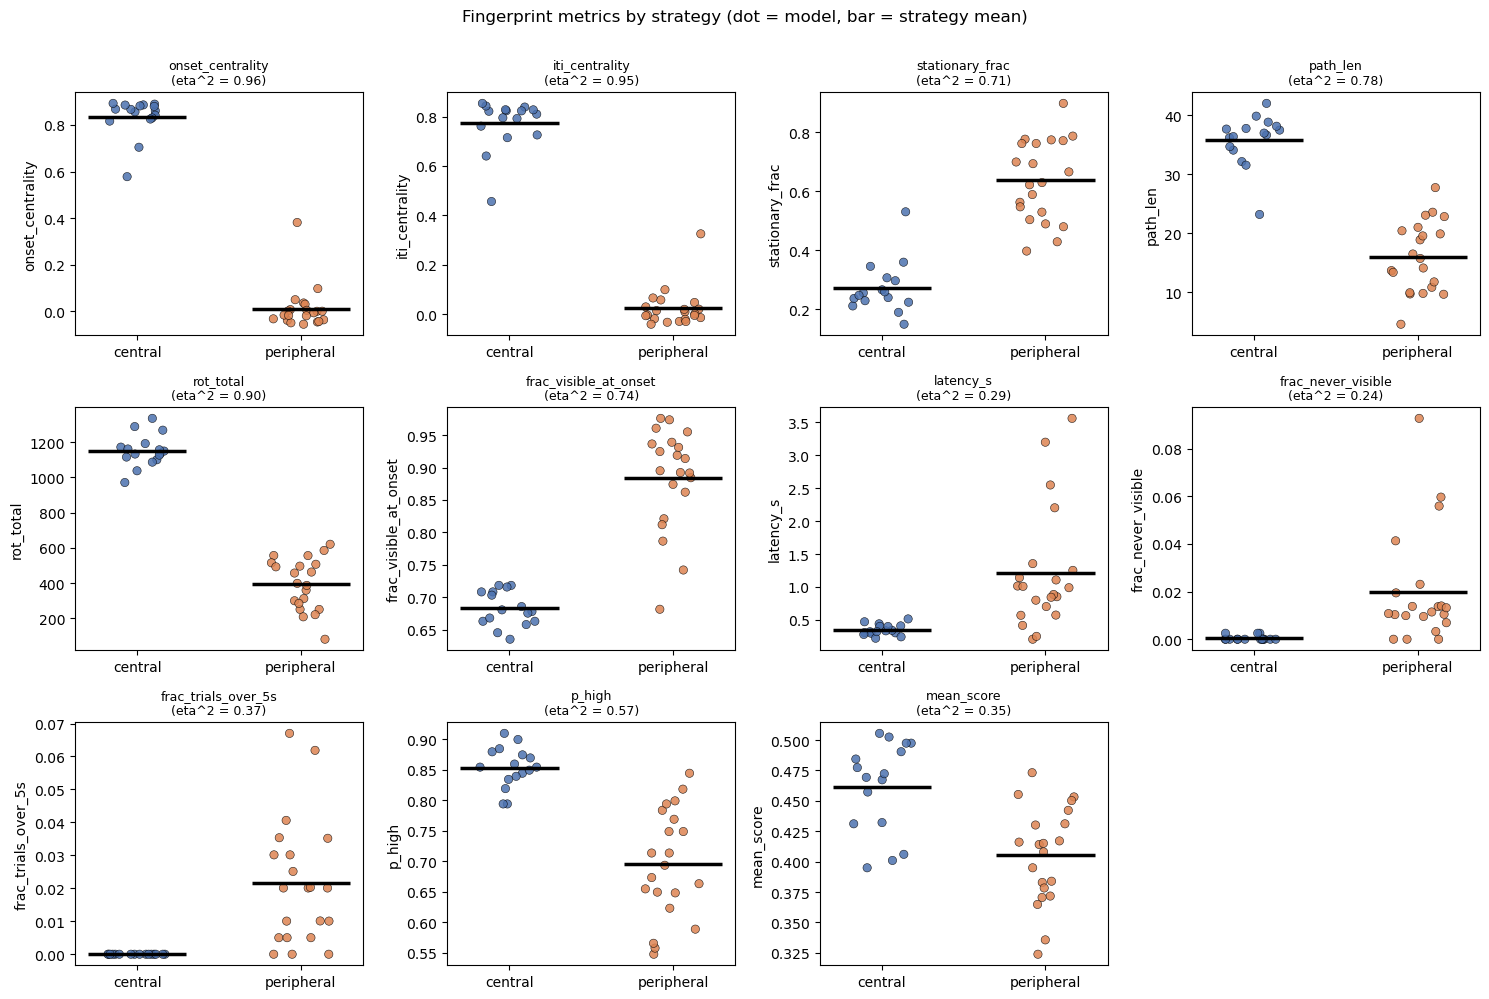

In [11]:
# plot central vs peripheral for each fingerprint metric (dot = model, bar = strategy mean)
ncol = 4
nrow = int(np.ceil(len(FP_METRICS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.3 * nrow))
for ax, m in zip(axes.ravel(), FP_METRICS):
    sns.stripplot(data=fingerprint, x='strategy', y=m, order=['central', 'peripheral'],
                  hue='strategy', palette=STRAT_PALETTE, size=6, jitter=0.18,
                  alpha=0.85, edgecolor='black', linewidth=0.4, legend=False, ax=ax)
    means = fingerprint.groupby('strategy')[m].mean()
    for i, g in enumerate(['central', 'peripheral']):
        ax.hlines(means[g], i - 0.3, i + 0.3, color='black', lw=2.5, zorder=5)
    e = var_table.set_index('metric').loc[m, 'eta2_between_strategy']
    ax.set_title(f'{m}\n(eta^2 = {e:.2f})', fontsize=9); ax.set_xlabel('')
for ax in axes.ravel()[len(FP_METRICS):]:
    ax.axis('off')
plt.suptitle('Fingerprint metrics by strategy (dot = model, bar = strategy mean)', y=1.005)
plt.tight_layout(); plt.show()

### Where each strategy stands at slice onset

Occupancy of the slice-onset position, split by strategy, with the octagon outline.

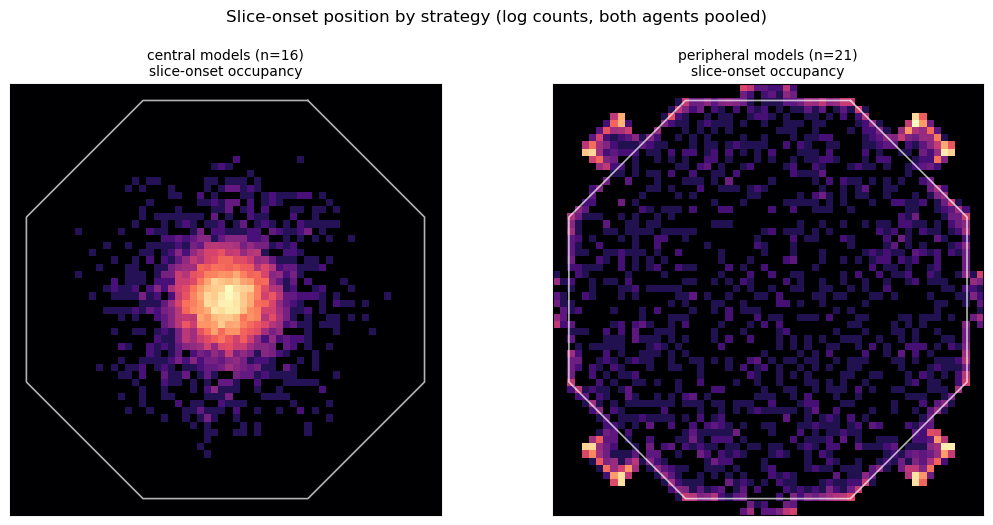

In [12]:
HIST_BINS = 60
extent = [-ARENA_RADIUS, ARENA_RADIUS, -ARENA_RADIUS, ARENA_RADIUS]
hrange = [[-ARENA_RADIUS, ARENA_RADIUS], [-ARENA_RADIUS, ARENA_RADIUS]]
strat_of = model_meta.set_index('model')['strategy'].to_dict()
slice_df['strategy'] = slice_df['model'].map(strat_of)

oct_x, oct_y = plot_octagon.calculate_coordinates(vertex=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, lab in zip(axes, ['central', 'peripheral']):
    sub = slice_df[slice_df['strategy'] == lab]
    H, _, _ = np.histogram2d(sub['x'].to_numpy(float), sub['z'].to_numpy(float),
                             bins=HIST_BINS, range=hrange)
    ax.imshow(np.log1p(H).T, origin='lower', extent=extent, cmap='magma', aspect='equal')
    ax.plot(oct_x, oct_y, color='white', lw=1.2, alpha=0.7)
    ax.set_title(f'{lab} models (n={ (model_meta.strategy==lab).sum() })\nslice-onset occupancy', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Slice-onset position by strategy (log counts, both agents pooled)', y=1.0)
plt.tight_layout(); plt.show()

## Stage 3 - multivariate fingerprint & tournament shortlist

PCA of the standardised metrics shows whether centrality is the main thing separating these models, or just one of several. Then a shortlist for the tournament: the two extremes, the most typical model of each strategy (its medoid), and the best in-session scorer of each. This spans the range of strategies while including the strongest models.

PC1 explains 66%, PC2 19% of fingerprint variance
corr(PC1, slice-onset centrality) = +0.88  (|r|~1 => centrality is the main axis; ~0 => something else is)


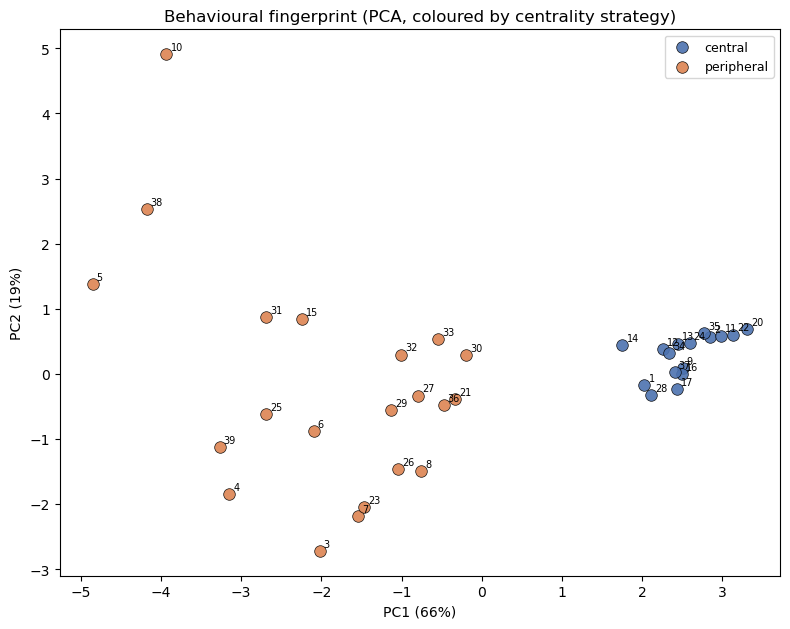

In [13]:
# standardise the metrics, leaving out the two centrality columns, so PCA shows what else varies
pca_metrics = ['stationary_frac', 'path_len', 'rot_total', 'frac_visible_at_onset',
               'latency_s', 'frac_never_visible', 'frac_trials_over_5s', 'p_high', 'mean_score']
X = fingerprint[pca_metrics].to_numpy(float)
X = np.where(np.isnan(X), np.nanmean(X, axis=0), X)          # fill the occasional missing latency
Xz = StandardScaler().fit_transform(X)
pca = PCA(n_components=2).fit(Xz)
pc = pca.transform(Xz)
fingerprint['pc1'], fingerprint['pc2'] = pc[:, 0], pc[:, 1]

r_pc1 = np.corrcoef(fingerprint['pc1'], fingerprint['onset_centrality'])[0, 1]
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.0%}, PC2 {pca.explained_variance_ratio_[1]:.0%} "
      f"of fingerprint variance")
print(f"corr(PC1, slice-onset centrality) = {r_pc1:+.2f}  "
      f"(|r|~1 => centrality is the main axis; ~0 => something else is)")

fig, ax = plt.subplots(figsize=(8, 6.4))
for lab in ['central', 'peripheral']:
    sub = fingerprint[fingerprint['strategy'] == lab]
    ax.scatter(sub['pc1'], sub['pc2'], s=70, color=STRAT_PALETTE[lab],
               edgecolor='black', linewidth=0.5, label=lab, alpha=0.9)
for _, r in fingerprint.iterrows():
    ax.annotate(int(r['model']), (r['pc1'], r['pc2']), fontsize=7, xytext=(3, 3),
                textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.set_title('Behavioural fingerprint (PCA, coloured by centrality strategy)')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

In [14]:
# pick the tournament shortlist: extremes, per-strategy medoid, per-strategy best in-session scorer
def medoid_model(sub):
    z = StandardScaler().fit_transform(sub[pca_metrics].fillna(sub[pca_metrics].mean()))
    return int(sub['model'].iloc[np.argmin(np.linalg.norm(z - z.mean(0), axis=1))])

picks = {}
picks['most_central'] = int(fingerprint.loc[fingerprint['onset_centrality'].idxmax(), 'model'])
picks['most_peripheral'] = int(fingerprint.loc[fingerprint['onset_centrality'].idxmin(), 'model'])
for lab in ['central', 'peripheral']:
    sub = fingerprint[fingerprint['strategy'] == lab]
    picks[f'typical_{lab}'] = medoid_model(sub)
    picks[f'best_scorer_{lab}'] = int(sub.loc[sub['mean_score'].idxmax(), 'model'])

shortlist = (pd.DataFrame({'role': list(picks), 'model': list(picks.values())})
             .drop_duplicates('model')
             .merge(fingerprint[['model', 'strategy', 'train_steps', 'onset_centrality',
                                 'p_high', 'mean_score']], on='model'))
print("Suggested tournament shortlist (spans the strategy axis, includes strongest in-session scorers):")
print("NB in-session score is a self-play proxy only — the tournament is the real ranking.")
shortlist.round(3)

Suggested tournament shortlist (spans the strategy axis, includes strongest in-session scorers):
NB in-session score is a self-play proxy only — the tournament is the real ranking.


,role,model,strategy,train_steps,onset_centrality,p_high,mean_score
0,most_central,22,central,4e6,0.893,0.910,0.506
1,most_peripheral,21,peripheral,4e6,-0.055,0.818,0.414
2,typical_central,2,central,4e6,0.856,0.854,0.497
3,typical_peripheral,32,peripheral,3e6,-0.015,0.769,0.430
4,best_scorer_peripheral,10,peripheral,4e6,0.382,0.784,0.473


### Final tournament shortlist

Chosen from this run's fingerprint under the score-based framing: **player score** (terminal 1.0 High / 0.4 Low / 0 lost) for performance, promptness (`pct_over_5s` = fraction of trials slower than 5 s to complete), and strategy coverage. Poorly-trained models are excluded — notably **model 5** (score-rank #34 of 37, with a slow-completion tail), which the earlier reward metric had flattered.

Eight entrants, **3 central / 2 intermediate / 3 peripheral**, each a healthy performer of its strategy:
- **Central (22, 20, 2):** the three best central scorers (all 0% trials over 5 s). 22 is both the most central and the #1 overall scorer.
- **Intermediate (14, 10):** the only two models in the centrality gap — 14 central-leaning, 10 peripheral-leaning. 10 carries the one notable completion tail (kept as the sole peripheral-leaning intermediate).
- **Peripheral (36, 15, 26):** best peripheral scorer + prompt (36, replacing 5), most High-seeking peripheral (15), and a typical 3e6 representative (26).

Ranks are out of the usable models (1 = highest); PC1 = strategy axis, PC2 = performance axis. Score is a self-play proxy — the tournament is the real ranking.

In [15]:
# final shortlist (role -> model), decided under the score + completion-time framing, tabulated from this run.
CURATED = [
    ('most_central (top scorer)', 22), ('strong_central', 20), ('typical_central', 2),
    ('intermediate_central_leaning', 14), ('intermediate_peripheral_leaning', 10),
    ('best_peripheral', 36), ('high_Phigh_peripheral', 15), ('typical_peripheral', 26),
]
rk = fingerprint.assign(
    cent_rk=fingerprint['onset_centrality'].rank(ascending=False).astype(int),
    pHigh_rk=fingerprint['p_high'].rank(ascending=False).astype(int),
    score_rk=fingerprint['mean_score'].rank(ascending=False).astype(int),
).set_index('model')
curated_tbl = pd.DataFrame([dict(
    role=role, model=m, strategy=rk.loc[m, 'strategy'], train=rk.loc[m, 'train_steps'],
    centrality=round(rk.loc[m, 'onset_centrality'], 2), cent_rk=int(rk.loc[m, 'cent_rk']),
    p_high=round(rk.loc[m, 'p_high'], 2), pHigh_rk=int(rk.loc[m, 'pHigh_rk']),
    mean_score=round(rk.loc[m, 'mean_score'], 3), score_rk=int(rk.loc[m, 'score_rk']),
    pct_over_5s=round(rk.loc[m, 'frac_trials_over_5s'], 3),
    stationary=round(rk.loc[m, 'stationary_frac'], 2),
    PC1=round(rk.loc[m, 'pc1'], 2), PC2=round(rk.loc[m, 'pc2'], 2),
) for role, m in CURATED])
curated_tbl

,role,model,strategy,train,centrality,cent_rk,p_high,pHigh_rk,mean_score,score_rk,pct_over_5s,stationary,PC1,PC2
0,most_central (top scorer),22,central,4e6,0.89,1,0.91,1,0.506,1,0.000,0.26,3.14,0.60
1,strong_central,20,central,4e6,0.88,6,0.87,6,0.503,2,0.000,0.19,3.31,0.69
2,typical_central,2,central,4e6,0.86,10,0.85,8,0.497,3,0.000,0.27,2.85,0.57
3,intermediate_central_leaning,14,central,4e6,0.58,16,0.88,3,0.490,5,0.000,0.53,1.76,0.44
4,intermediate_peripheral_leaning,10,peripheral,4e6,0.38,17,0.78,21,0.473,8,0.067,0.76,-3.93,4.91
5,best_peripheral,36,peripheral,3e6,0.00,25,0.75,23,0.455,13,0.005,0.55,-0.48,-0.48
6,high_Phigh_peripheral,15,peripheral,4e6,0.03,21,0.84,11,0.453,14,0.020,0.79,-2.24,0.84
7,typical_peripheral,26,peripheral,3e6,-0.04,32,0.69,27,0.442,16,0.005,0.63,-1.05,-1.47


## Reading the results

- **Stage 1** places every model on one axis, its position when the trial starts. The plots show whether the models spread smoothly or fall into groups, and whether the two splits agree on which group each model is in.
- **Stage 2** separates what the strategy is from how models differ in other ways. Metrics that track the central/peripheral split (centrality, wall-visibility-at-onset) are part of the strategy. Metrics that vary within a strategy (scanning, scoring) tell similar models apart on a second dimension.
- **Stage 3** checks whether centrality is the main axis in the full metric set (PC1 correlation) and proposes a shortlist that spans the range while including the best in-session scorers.

**Caveats.** In self-play, where an agent stands at slice onset depends partly on its opponent, so centrality reflects both agents, not one model alone. The tournament (models vs *other* models) is what actually ranks competitive strength. As in prior sim runs, inference policies are near-deterministic and often split into two behaviours across models, so read the per-model bars, not just strategy means. Training length (4e6 vs 3e6, model >= 25) is the one real parameter difference; the strategy-by-training-length crosstab shows whether the shorter run pushed models toward one strategy.